In [1]:
import numpy as np
import matplotlib.pyplot as plt
from rkhs import RKHS
import fif

In [2]:
# Generate synthetic data on the interval [0,1]
# Here we define a smooth function for demonstration purposes.
x = np.linspace(0, 1, 50)
# Example function: f(x) = sin(2πx) + 0.5*cos(3πx)
f_values = np.sin(2 * np.pi * x) + 0.5 * np.cos(3 * np.pi * x)
data_series = np.column_stack((x, f_values))
data_series[:5]

array([[0.        , 0.5       ],
       [0.02040816, 0.61865674],
       [0.04081633, 0.71711296],
       [0.06122449, 0.79431106],
       [0.08163265, 0.84989223]])

In [3]:
x.shape

(50,)

In [4]:
# Create an RKHS object with m basis functions and a specified fractal depth.
m = 5
fractal_depth = 2
rkhs_obj = RKHS(data_series=data_series, m=m, fractal_depth=fractal_depth)

Vertical scaling factors s_values were not provided, so they were initialised randomly.
Building the Basis functions for the RKHS:
	Built F_[u_1].
	Built F_[u_2].
	Built F_[u_3].
	Built F_[u_4].
	Built F_[u_5].
Established the refined x grid with 117650 points.
Built matrix A = [<F_[u_i], F_[u_j]>].
Built matrix B = inverse(A).


In [5]:
# Print out the matrix A (inner products) and its inverse B.
print("Matrix A (inner products between fractal basis functions):")
print(np.round(rkhs_obj.A, decimals=2))
print("\nMatrix B (inverse of A):")
print(np.round(rkhs_obj.B, decimals=2))

Matrix A (inner products between fractal basis functions):
[[ 1.   -0.    0.05 -0.   -0.02]
 [-0.    0.51  0.02  0.    0.  ]
 [ 0.05  0.02  1.45  0.09 -0.05]
 [-0.    0.    0.09  0.81 -0.08]
 [-0.02  0.   -0.05 -0.08  1.  ]]

Matrix B (inverse of A):
[[ 1.    0.   -0.03  0.01  0.02]
 [ 0.    1.96 -0.03 -0.01 -0.01]
 [-0.03 -0.03  0.7  -0.08  0.03]
 [ 0.01 -0.01 -0.08  1.25  0.1 ]
 [ 0.02 -0.01  0.03  0.1   1.01]]


In [6]:
np.linalg.eigvals(rkhs_obj.A)

array([1.4723976 , 0.99180656, 1.02107461, 0.77450157, 0.50997317])


Kernel function k(0, 0) = 5.8900416275038365


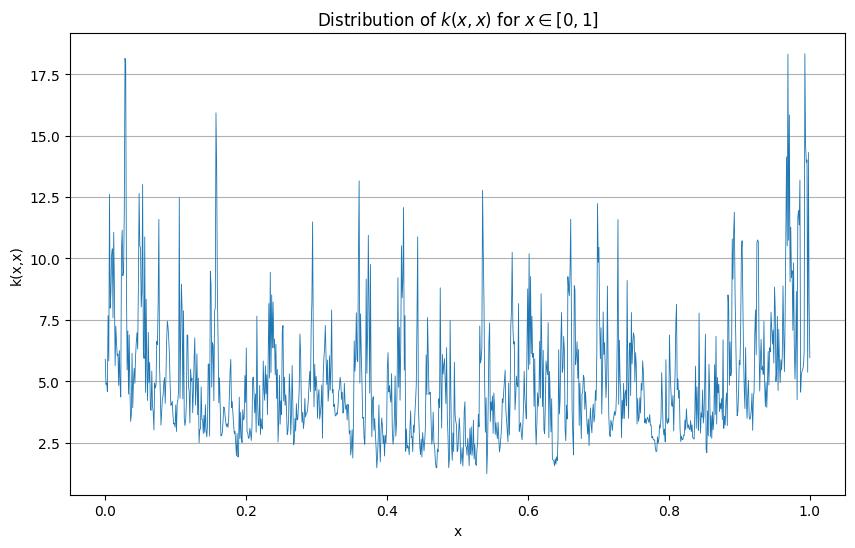

In [7]:
# Evaluate the kernel function between two sample points.
x1 = 0
x2 = 0
k_val = rkhs_obj.kernel_function(x1, x2)
print(f"\nKernel function k({x1}, {x2}) = {k_val}")
x_plot = np.linspace(0, 1, 1000)
plt.figure(figsize=(10, 6))

kf = np.array([rkhs_obj.kernel_function(x,x) for x in x_plot])
# rkhs_obj.kernel_array(x_plot, x_plot)
plt.plot(x_plot, kf, linewidth=0.6)
plt.title(r"Distribution of $k(x, x)$ for $x \in [0, 1]$")
plt.xlabel("x")
# plt.legend()
plt.ylabel("k(x,x)")
plt.grid(axis='y')
plt.show()


Kernel function k(1, 1) = 5.957475019365849


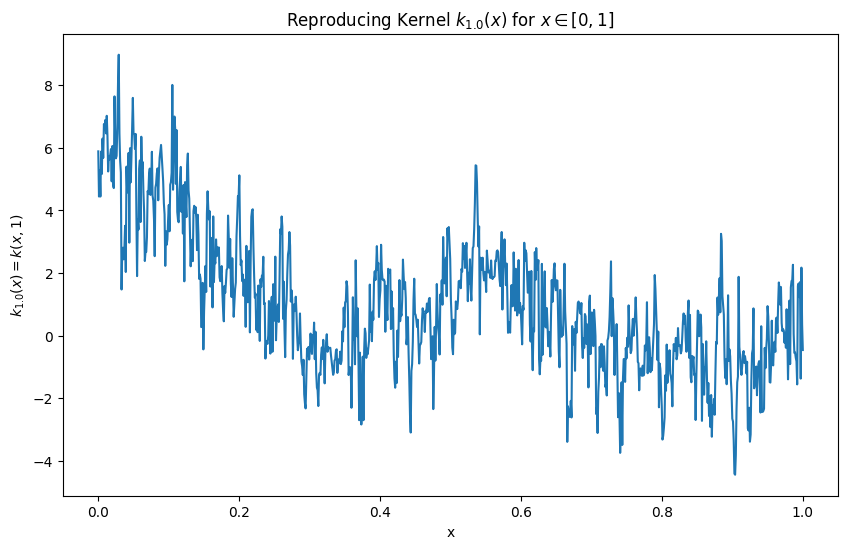

In [11]:
# Evaluate the kernel function between two sample points.
x1 = 1
x2 = 1
k_val = rkhs_obj.kernel_function(x1, x2)
print(f"\nKernel function k({x1}, {x2}) = {k_val}")
x_plot = np.linspace(0, 1, 1000)
def reproducing_kernel(x_):
    return lambda x: rkhs_obj.kernel_array(x, (np.zeros_like(x)+x_))

y_plot = reproducing_kernel(0)(x_plot)
plt.figure(figsize=(10, 6))
plt.plot(x_plot, y_plot)
plt.title(r"Reproducing Kernel $k_{1.0}(x)$ for $x \in [0, 1]$")
plt.xlabel("x")
plt.ylabel(r"$k_{1.0}(x) = k(x,1)$")
plt.show()

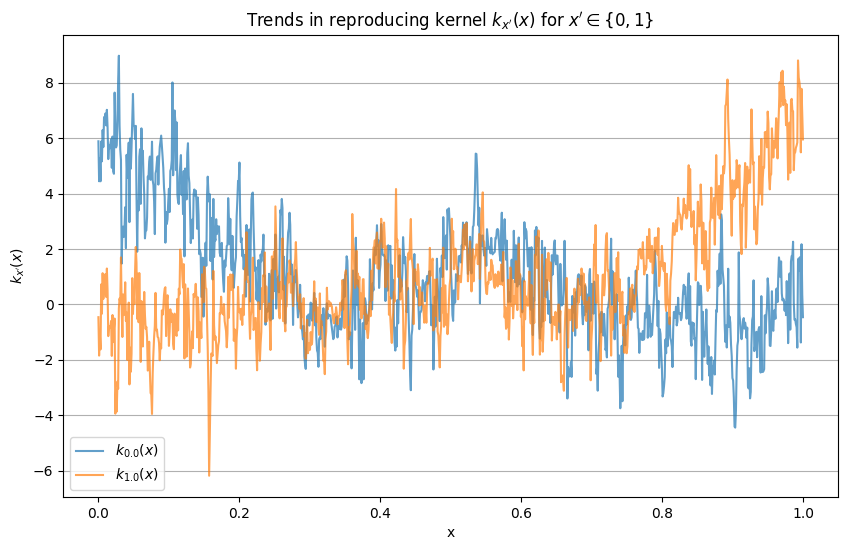

In [42]:
x_plot = np.linspace(0, 1, 1000)
plt.figure(figsize=(10, 6))
for i in range(2):
    x_ = i/1.0
    y_plot = reproducing_kernel(x_)(x_plot)
    x_str = f"{x_}"
    label_str = r"$k_{"
    label_str += x_str
    label_str += r"}(x)$"
    plt.plot(x_plot, y_plot, label=label_str, alpha=0.7)
plt.title(r"Trends in reproducing kernel $k_{x'}(x)$ for $x' \in \{0, 1\}$")
plt.xlabel("x")
plt.ylabel(r"$k_{x'}(x)$")
plt.legend()
plt.grid(axis='y')
plt.show()

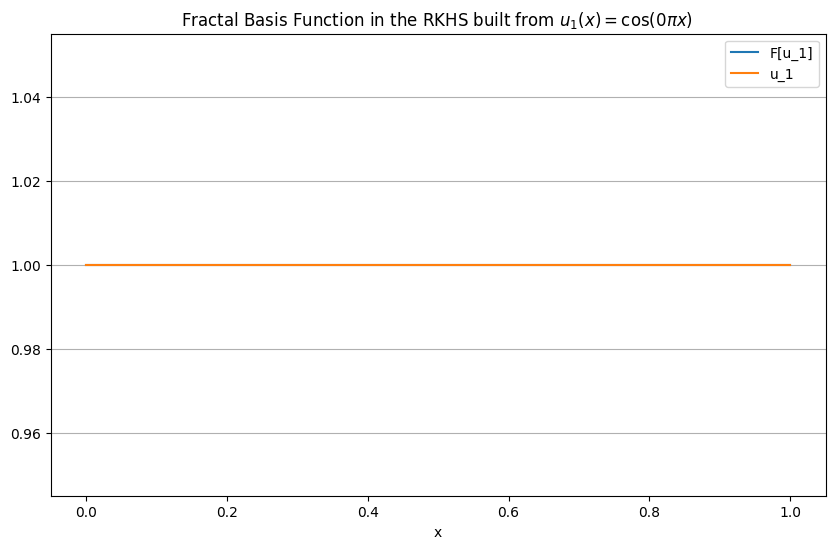

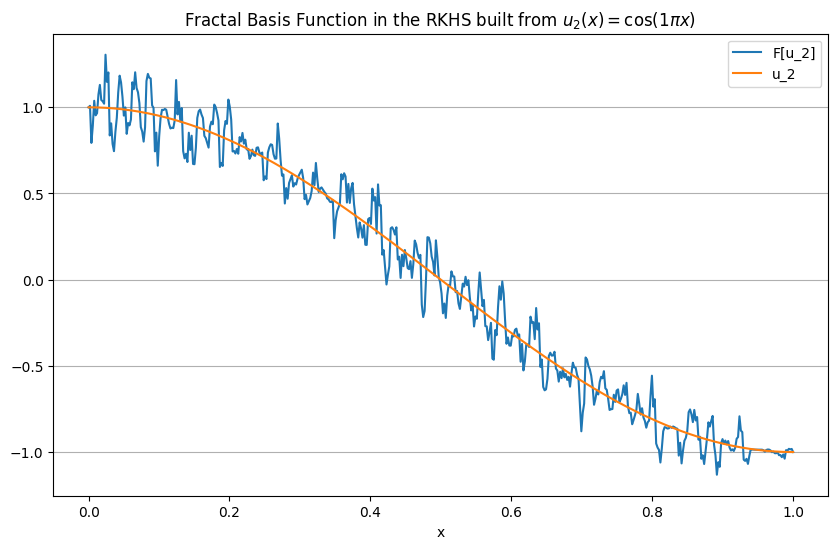

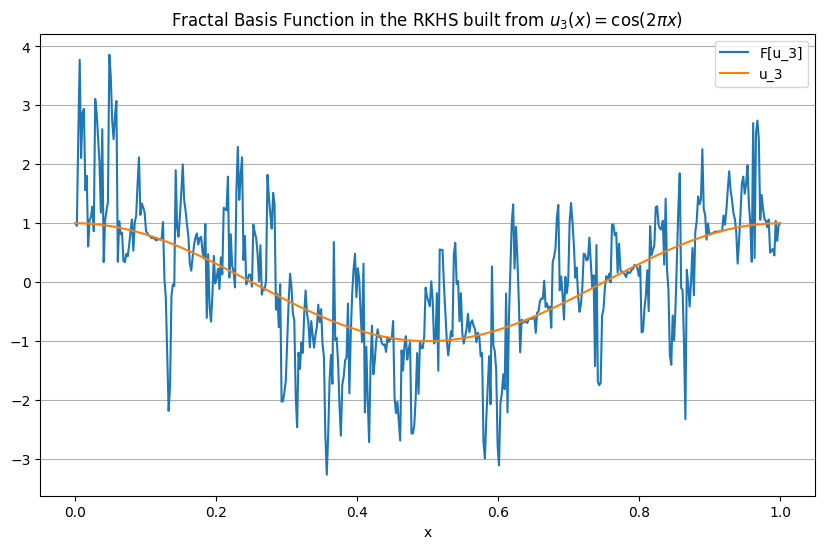

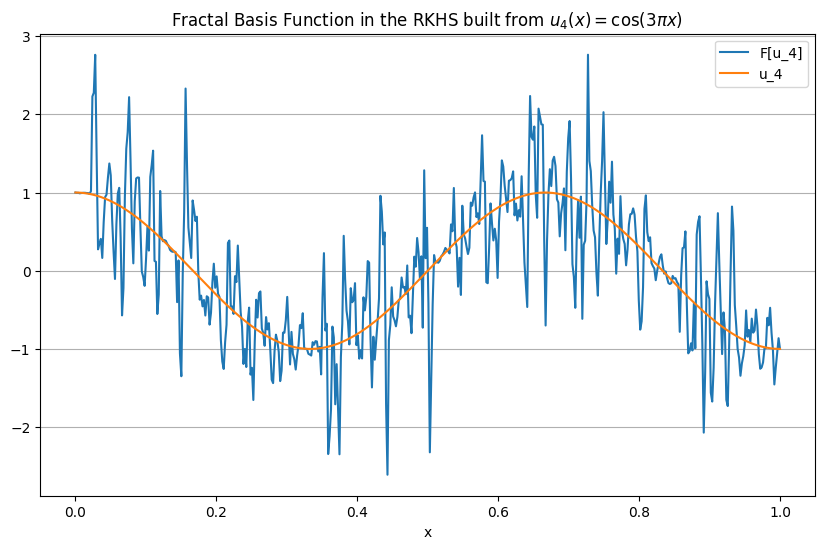

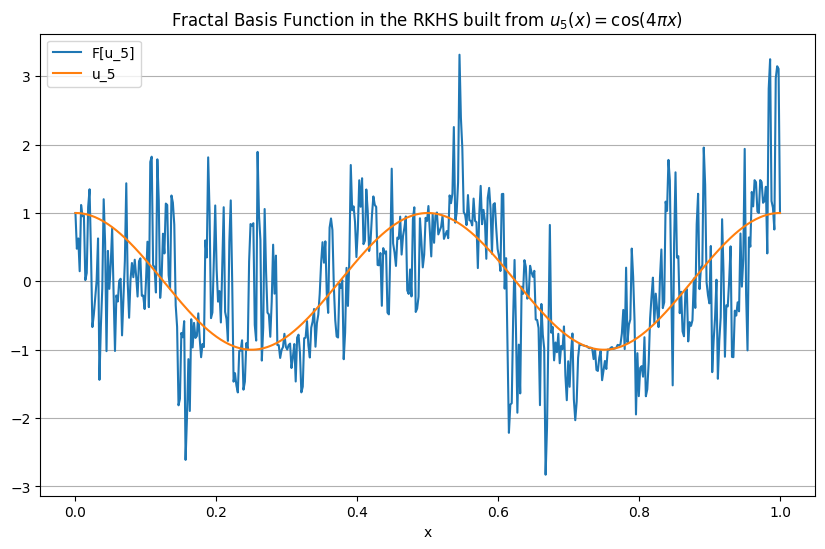

In [ ]:
# Plot the fractal basis functions over the interval [0, 1].
x_plot = np.linspace(0, 1, 500)
for i in range(1, m+1):
    plt.figure(figsize=(10, 6))
    Fi = rkhs_obj.fractal_basis[f"{i}"]
    ui = fif.u(i-1)
    y_vals = np.array([Fi(xi) for xi in x_plot])
    plt.plot(x_plot, y_vals, label=f"F[u_{i}]")
    plt.plot(x_plot, ui(x_plot), label=f"u_{i}")
    plt.title(rf"Fractal Basis Function in the RKHS built from $u_{i}(x) = \cos({i-1}\pi x)$ ")
    plt.xlabel("x")
    plt.legend()
    plt.grid(axis='y')
    plt.show()

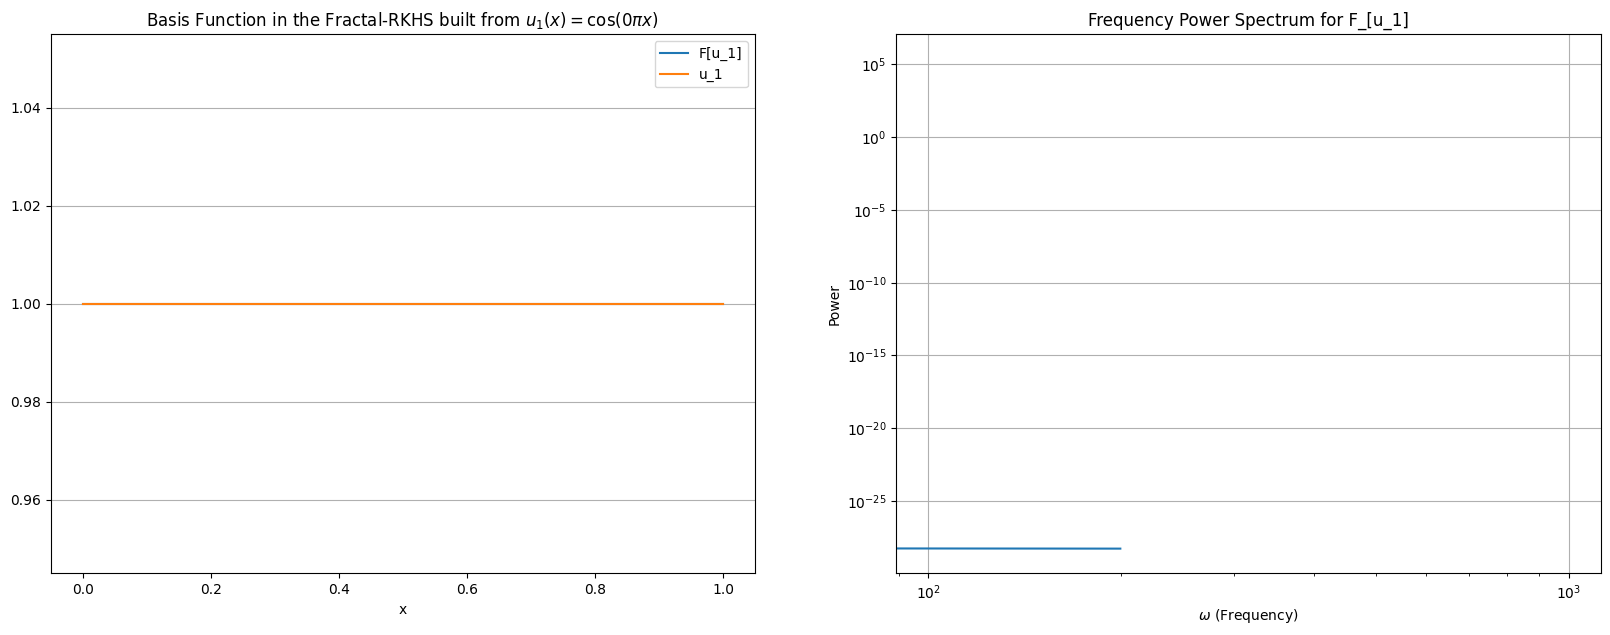

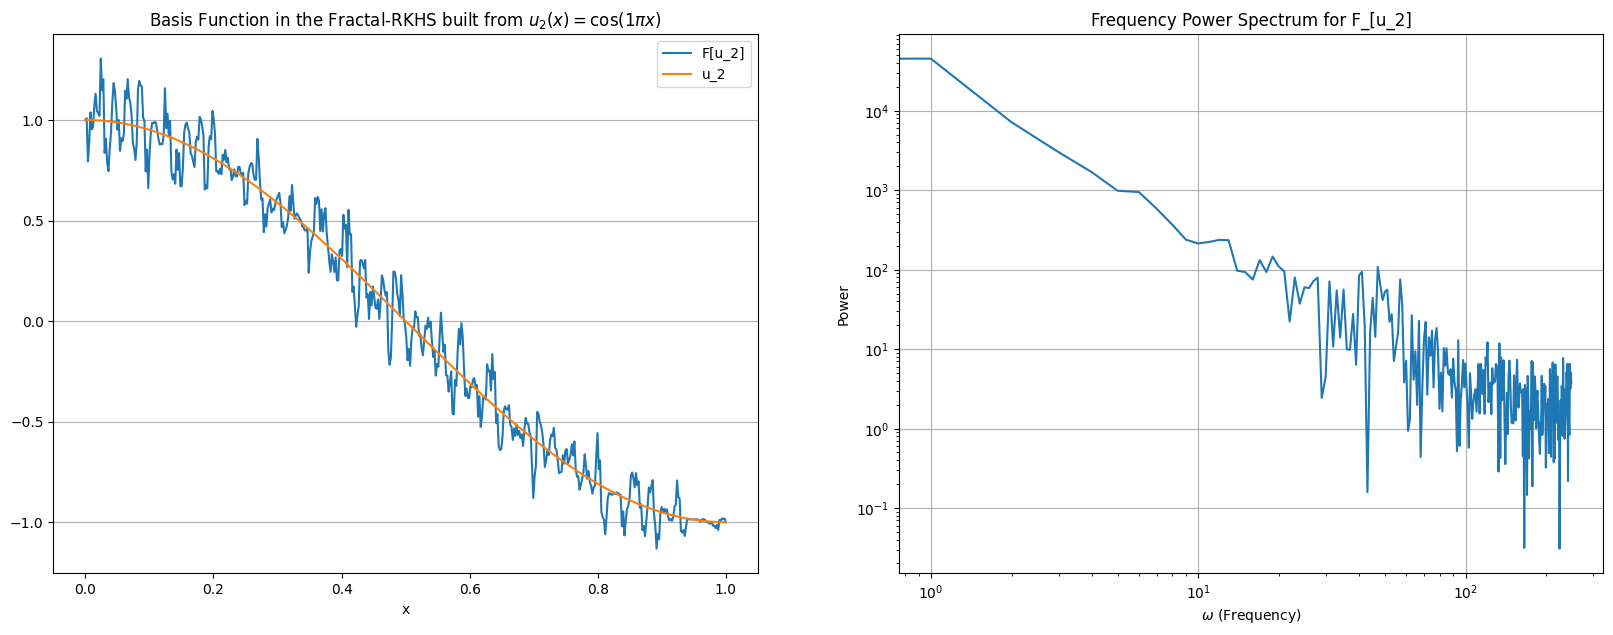

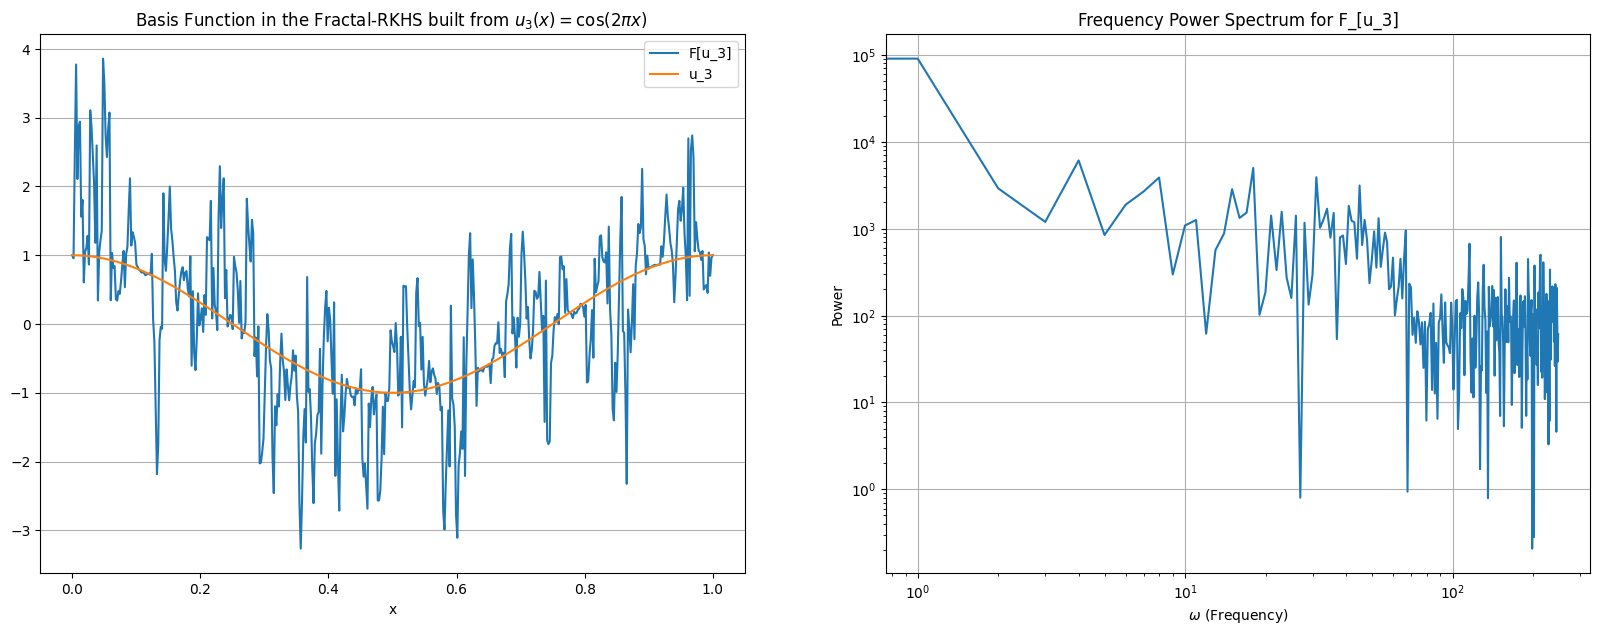

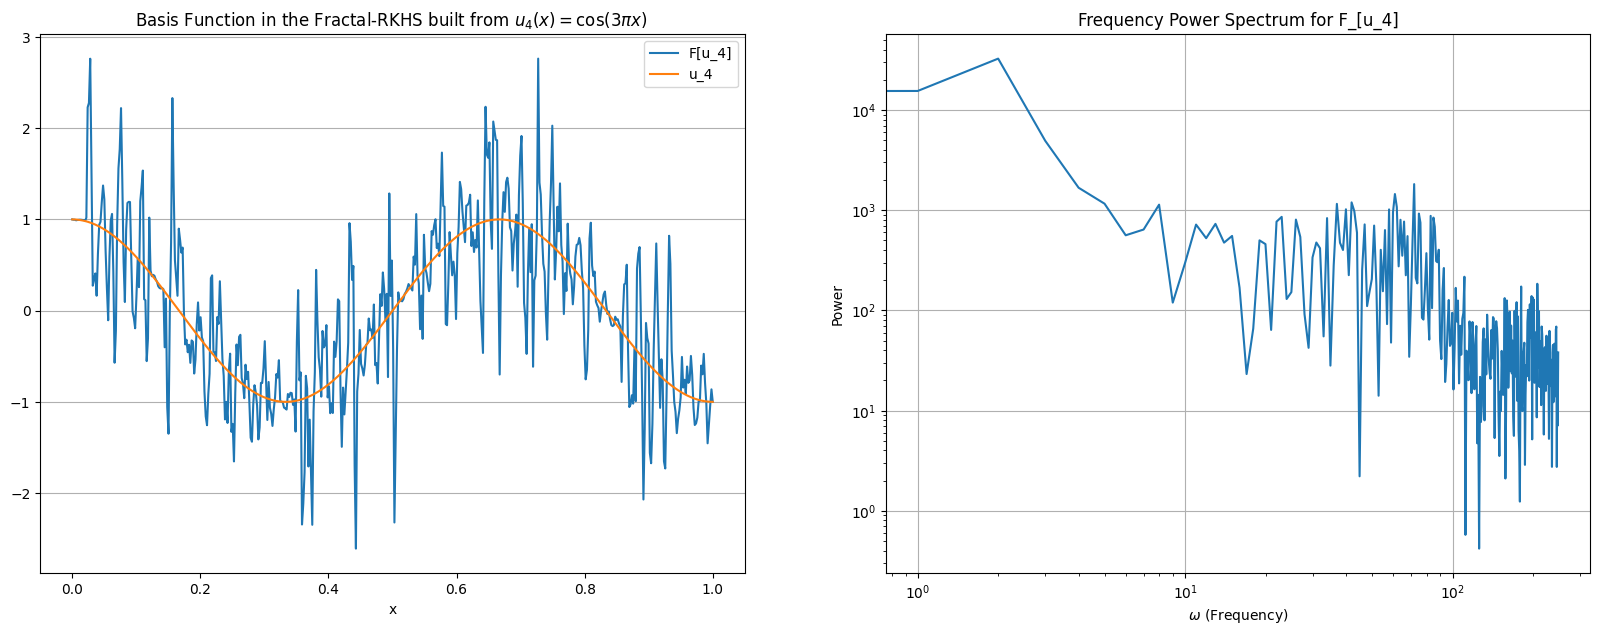

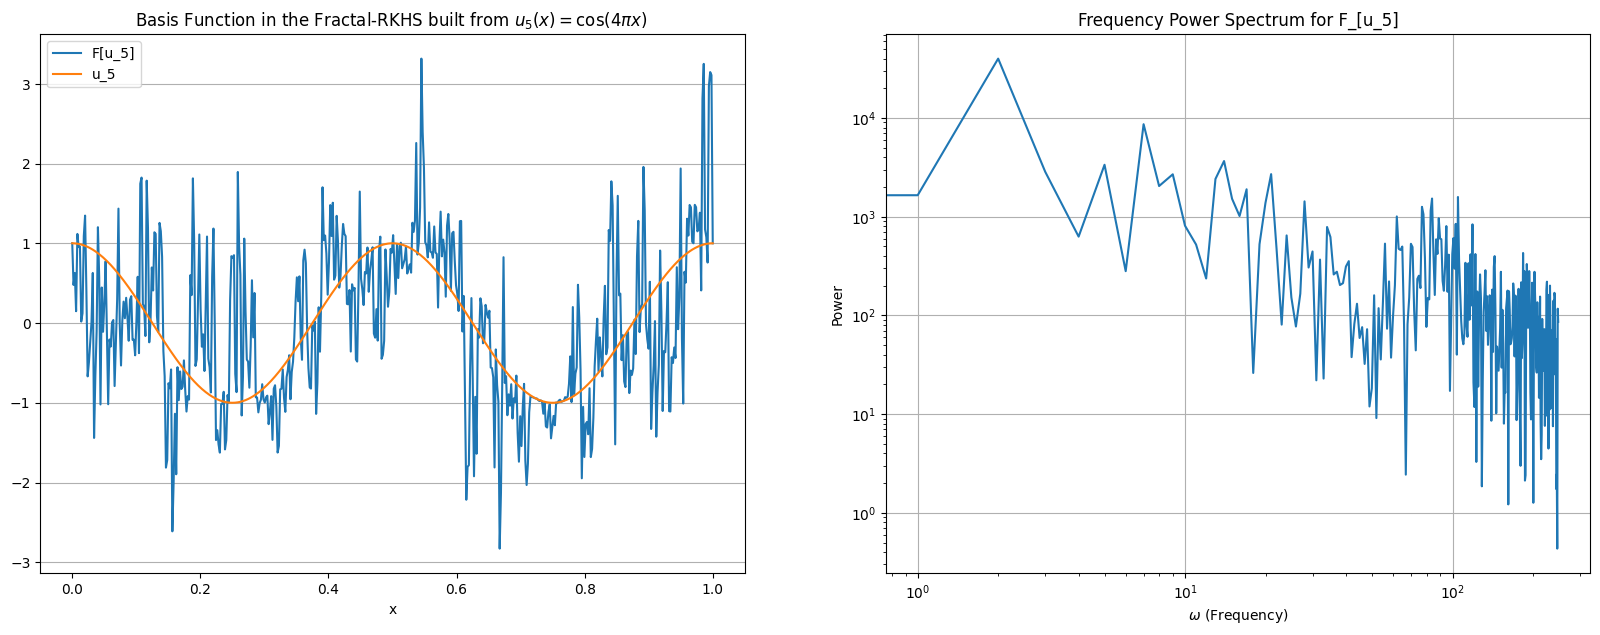

In [40]:
x_plot = np.linspace(0, 1, 500)

for i in range(1, m+1):
    fig, axs = plt.subplots(1, 2, figsize=(10*2, 7))
    Fi = rkhs_obj.fractal_basis[f"{i}"]
    ui = fif.u(i-1)
    y_vals = np.array([Fi(xi) for xi in x_plot])

    # Plot the functions
    axs[0].plot(x_plot, y_vals, label=f"F[u_{i}]")
    axs[0].plot(x_plot, ui(x_plot), label=f"u_{i}")
    axs[0].set_title(rf"Basis Function in the Fractal-RKHS built from $u_{i}(x) = \cos({i-1}\pi x)$ ")
    axs[0].set_xlabel("x")
    axs[0].legend()
    axs[0].grid(axis='y')

    # Plot their spectrums
    fft_values = np.fft.fft(y_vals)
    freqs = np.fft.fftfreq(len(x_plot), x_plot[1]-x_plot[0])
    power_spectrum = np.abs(fft_values)**2

    positive_freqs = freqs[:len(freqs)//2]
    positive_power = power_spectrum[:len(power_spectrum)//2]
    mask = (positive_power > 0)

    axs[1].loglog(positive_freqs[mask], positive_power[mask])
    axs[1].set_title(f"Frequency Power Spectrum for F_[u_{i}]")
    axs[1].set_xlabel(r"$\omega$ (Frequency)")
    axs[1].set_ylabel("Power")
    axs[1].grid(axis='both')
    plt.show()

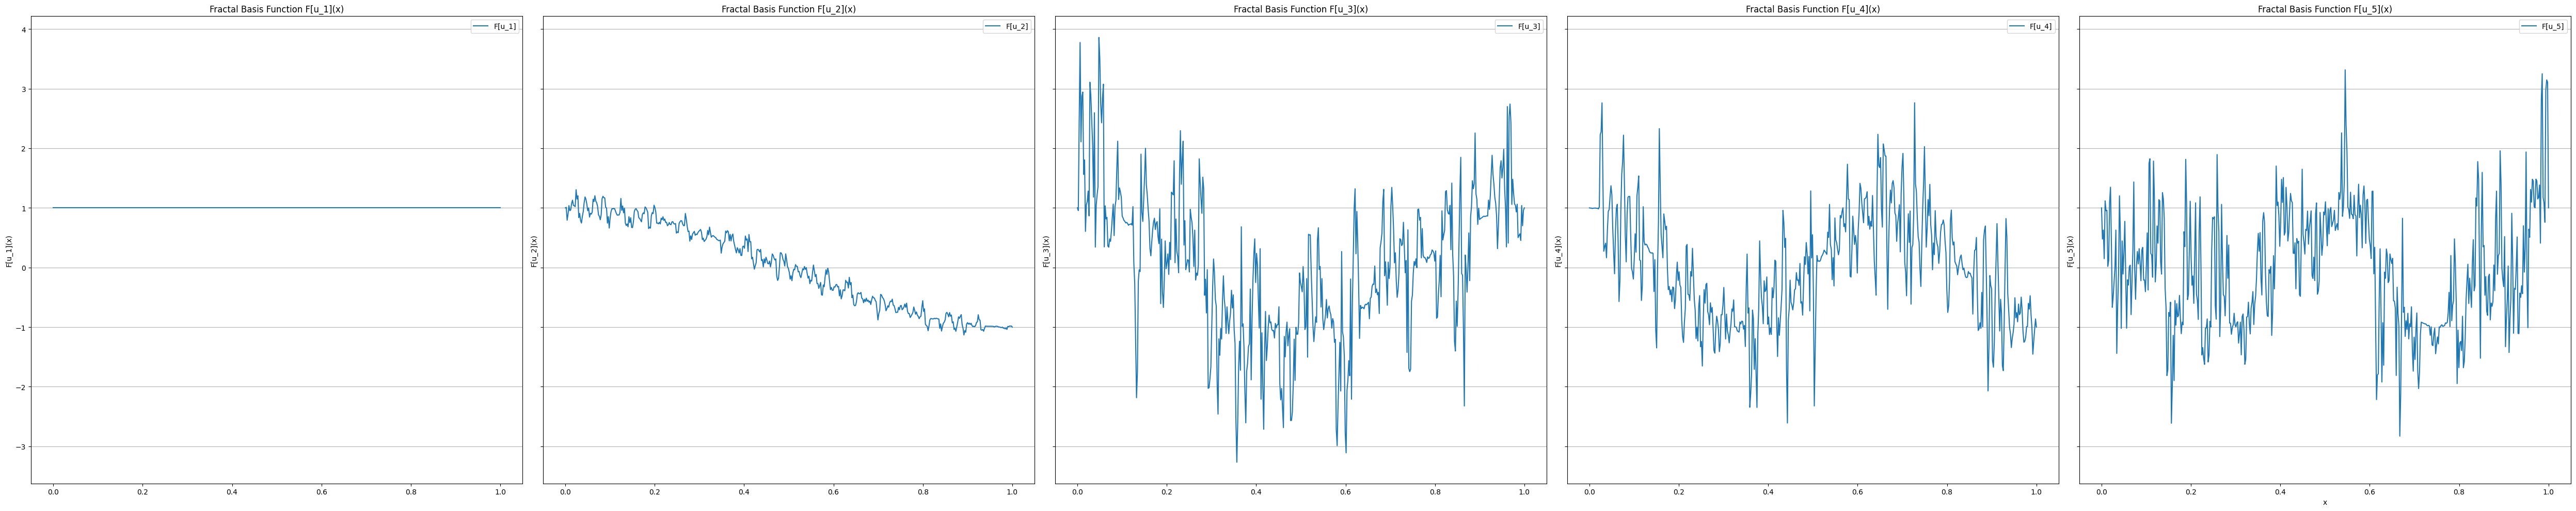

In [ ]:
# Plot the fractal basis functions over the interval [0, 1].
x_plot = np.linspace(0, 1, 500)

fig, axs = plt.subplots(1, m, figsize=(10*m, 10), sharey=True)

for i in range(1, m+1):
    Fi = rkhs_obj.fractal_basis[f"{i}"]
    y_vals = np.array([Fi(xi) for xi in x_plot])
    axs[i-1].plot(x_plot, y_vals, label=f"F[u_{i}]")
    axs[i-1].set_title(f"Fractal Basis Function F[u_{i}](x)")
    axs[i-1].set_ylabel(f"F[u_{i}](x)")
    axs[i-1].legend()
    axs[i-1].grid(axis='y')

axs[-1].set_xlabel("x")
plt.tight_layout()
plt.show()